In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib

# Reload modules to pick up changes
if "helper" in sys.modules:
    importlib.reload(sys.modules["helper"])
if "plotting" in sys.modules:
    importlib.reload(sys.modules["plotting"])

import helper
import plotting

import os
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

import plotting
import importlib
importlib.reload(plotting)
from pathlib import Path

import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


Plotting geometry with Fresnel semicircles...


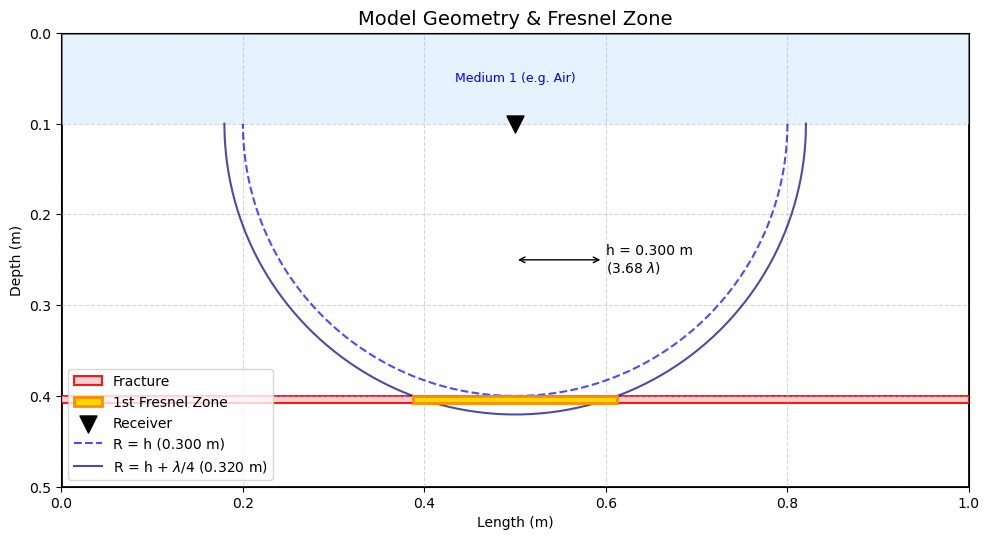


--- Geometry Analysis Results ---
wavelength_m: 0.08159317231497298
fracture_depth_m: 0.3
fracture_depth_lambda: 3.6767782338688115
fracture_thickness_m: 0.008159317231497298
fracture_thickness_lambda: 0.09999999999999999
horizontal_resolution_m: 0.1124947385781764
min_far_field_depth_m: 0.2451185489245875
first_fresnel_radius_m: 0.1124947385781764
is_in_far_field: True


In [9]:
# --- Function 1: Analyze and Plot Geometry ---

# User settings
length = 1.0     # Model length (m)
depth = 0.5      # Model depth (m)
x_receiver = 0.5 # Receiver X position (m)
y_receiver = 0.1 # Receiver Y position (m)
f_central = 1.5e9 # Hz
epsilon_r = 6.0   # Background permittivity

print("Plotting geometry with Fresnel semicircles...")

results = plotting.analyze_and_plot_model_geometry(
    length=length,
    depth=depth,
    f_central=f_central,
    epsilon_r=epsilon_r,
    fracture_depth_m=0.3,            # Distance from receiver in meters
    fracture_depth_lambda=None,      # Set to None to use meters
    fracture_thickness_lambda=0.1,   # Thickness can still be fraction of wavelength (or use fracture_thickness_m)
    source_offset=0.1,               # Source-Receiver offset for far-field calculation (m)
    x_receiver=x_receiver,
    y_receiver=y_receiver,
    show_plot=True
)

print("\n--- Geometry Analysis Results ---")
for k, v in results.items():
    print(f"{k}: {v}")


Generating alternating model...


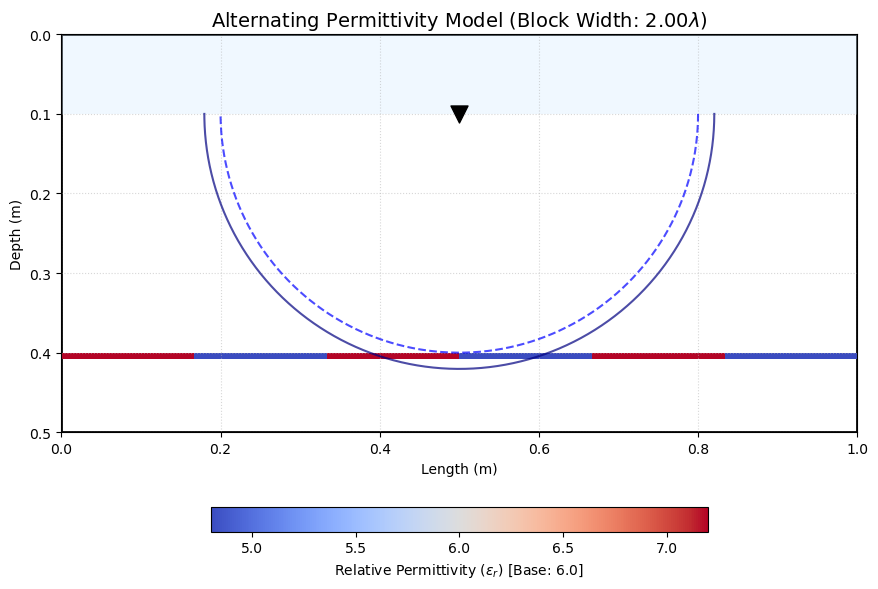


--- Model Generation Complete ---
File written to: ..\True_and_Baseline_Models\alternating_permittivity_model_6.in
Block width (m): 0.1667
Permittivity values: 7.200 and 4.800

File Preview (first 20 lines):
#title: Alternating Permittivity Model
#domain: 1.0 0.5 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 1e-08

#material: 6.0 0.01 1 0 ice
#material: 1 0 1 0 air

#material: 7.2000 0.01 1 0 fracture_alt_plus
#material: 4.8000 0.01 1 0 fracture_alt_minus

#box: 0 0.400000 0 1.0 0.5 0.0002 air
#box: 0 0 0 1.0 0.400000 0.0002 ice

// Fracture Blocks (6 blocks)
#box: 0.000000 0.091841 0 0.166667 0.100000 0.0002 fracture_alt_plus
#box: 0.166667 0.091841 0 0.333333 0.100000 0.0002 fracture_alt_minus
#box: 0.333333 0.091841 0 0.500000 0.100000 0.0002 fracture_alt_plus
#box: 0.500000 0.091841 0 0.666667 0.100000 0.0002 fracture_alt_minus
#box: 0.666667 0.091841 0 0.833333 0.100000 0.0002 fracture_alt_plus



In [10]:
# --- Function 2: Generate Alternating Permittivity Model ---


# User settings for Function 2
out_filename = Path("..") / "True_and_Baseline_Models" / "alternating_permittivity_model_6.in"

length = 1.0     # Model length (m)
depth = 0.5      # Model depth (m)
x_receiver = 0.5 # Receiver X position (m)
y_receiver = 0.1 # Receiver Y position (m)
f_central = 1.5e9 # Hz
epsilon_r = 6.0   # Background permittivity

print("\nGenerating alternating model...")

# Generate model with absolute inputs (meters)
# Block width is still lambda-fraction for now, or could change.
model_info = plotting.generate_alternating_block_model(
    filename=str(out_filename),
    length=length,
    depth=depth,
    f_central=f_central,
    epsilon_r=epsilon_r,
    fracture_depth_m=0.3,            # Fracture depth from receiver (absolute meters)
    fracture_depth_lambda=None,      # Set to None
    fracture_thickness_lambda=0.1,   # Fracture aperture
    block_width_lambda=2,          # Alternating block width
    percent_delta=20.0,               # Permittivity variation
    baseline_conductivity=0.01,      # Conductivity (constant)
    x_receiver=x_receiver,
    y_receiver=y_receiver,
    show_plot=True,
    
    # gprMax specific params
    dx_dy_dz=(0.0002, 0.0002, 0.0002),  # Finer mesh for detail
    time_window=10e-9,
    background_material='ice'
)

print(f"\n--- Model Generation Complete ---")
print(f"File written to: {model_info['filename']}")
print(f"Block width (m): {model_info['block_width_m']:.4f}")
print(f"Permittivity values: {model_info['epsilon_plus']:.3f} and {model_info['epsilon_minus']:.3f}")

# Optional: Preview created file
with open(out_filename, 'r') as f:
    print("\nFile Preview (first 20 lines):")
    print("".join(f.readlines()[:20]))

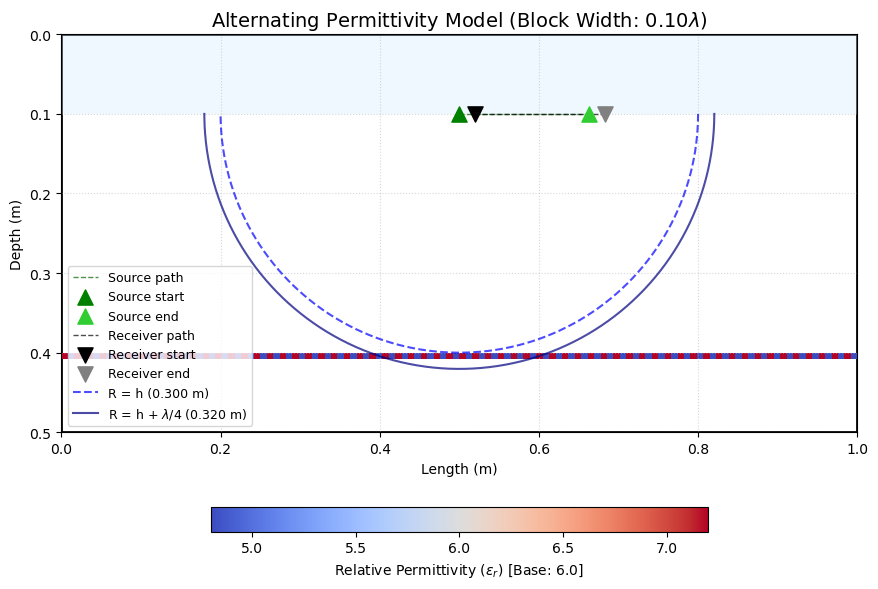

Small B-scan model created.
File: ..\True_and_Baseline_Models\alternating_permittivity_model_6_bscan.in
Traces: 5
Step: 0.040797 m (0.5 lambda)
Run with gprMax using: -n 5
Step commands found:
#src_steps: 0.04079658615748649 0 0
#rx_steps: 0.04079658615748649 0 0


In [20]:
# --- Small B-scan test: few traces for quick validation ---
out_filename_bscan = Path("..") / "True_and_Baseline_Models" / "alternating_permittivity_model_6_bscan.in"

bscan_info = plotting.generate_alternating_block_model(
    filename=str(out_filename_bscan),
    length=length,
    depth=depth,
    f_central=f_central,
    epsilon_r=epsilon_r,
    fracture_depth_m=0.3,
    fracture_depth_lambda=None,
    fracture_thickness_lambda=0.1,
    block_width_lambda=0.1,
    percent_delta=20.0,
    baseline_conductivity=0.01,
    x_receiver=x_receiver,
    y_receiver=y_receiver,
    show_plot=True,
    dx_dy_dz=(0.0002, 0.0002, 0.0002),
    time_window=10e-9,
    background_material='ice',
    bscan_n_traces=5,        # small trace count for quick tests
    bscan_step_lambda=0.5,  # step = 0.10 * wavelength
    tx_rx_offset=0.02
)

print("Small B-scan model created.")
print(f"File: {bscan_info['filename']}")
print(f"Traces: {bscan_info['bscan_n_traces']}")
print(f"Step: {bscan_info['bscan_step_m']:.6f} m ({bscan_info['bscan_step_lambda']} lambda)")
print("Run with gprMax using: -n 5")

# Explicitly show stepping lines in the generated file.
with open(out_filename_bscan, 'r') as f:
    lines = f.readlines()
step_lines = [ln.strip() for ln in lines if ln.startswith('#src_steps') or ln.startswith('#rx_steps')]
if step_lines:
    print("Step commands found:")
    for ln in step_lines:
        print(ln)
else:
    print("No #src_steps/#rx_steps found in file.")

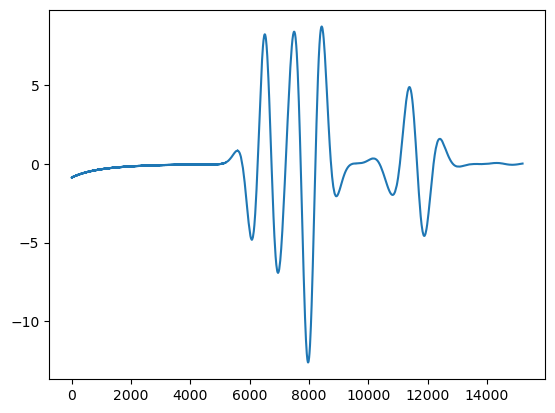

In [21]:
rxnumber = 1
rxcomponent = 'Ez'
alternating_results_1 = r'..\True_and_Baseline_Models\alternating_permittivity_model_6.out'

alternating_data, dt = get_output_data(alternating_results_1, rxnumber, rxcomponent)
plt.plot(alternating_data[6000:])

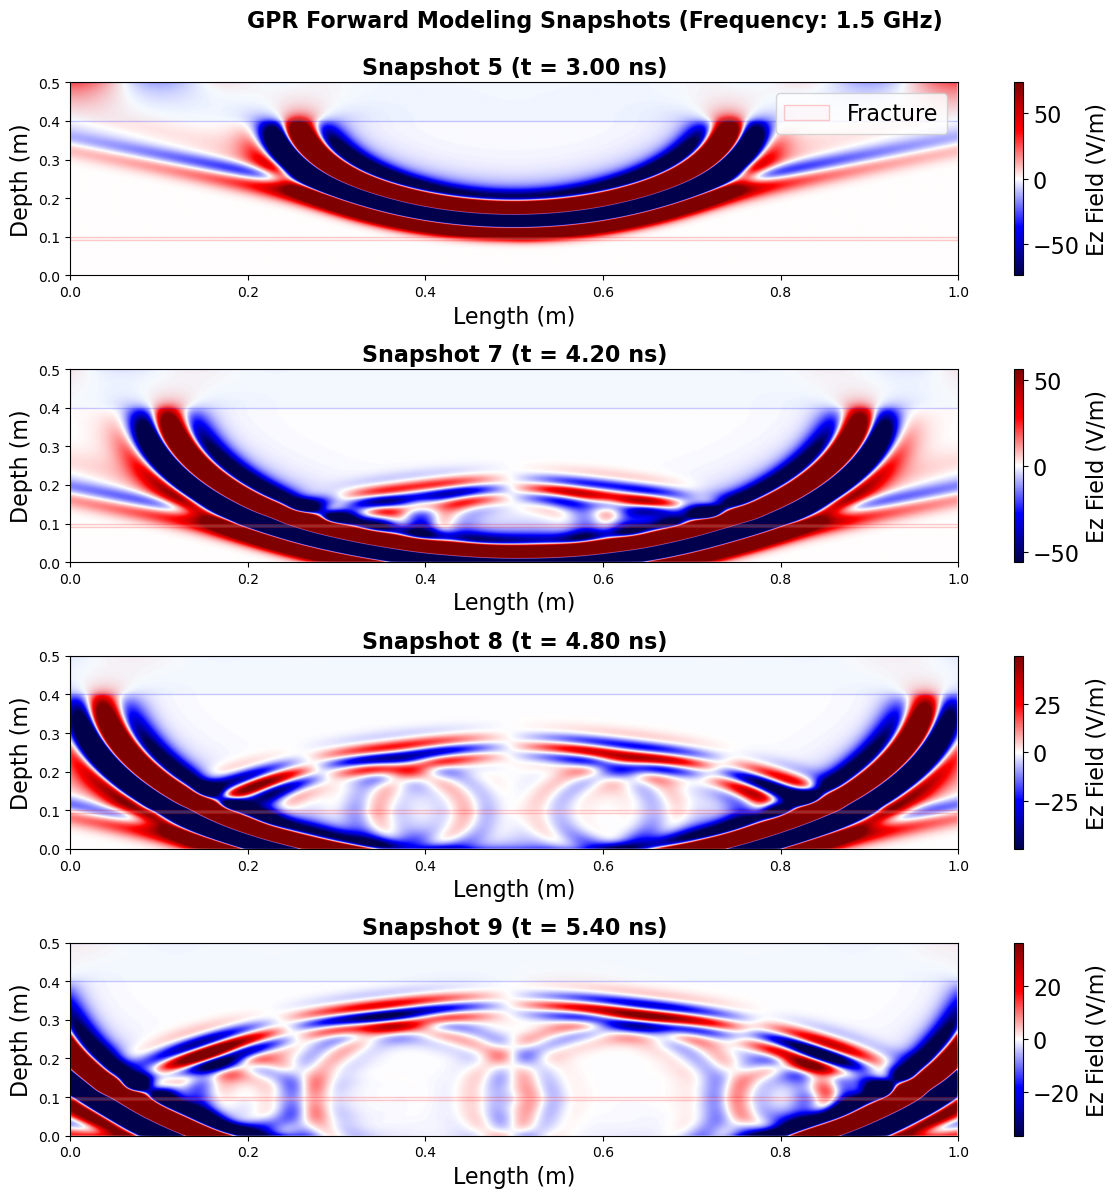

In [46]:

# Model dimensions
length = 1.0   # x-length (m)
depth  = 0.5   # y-depth (m)
upper_layer_thickness = 0.1  # m
fracture_y0 = 0.091841
fracture_y1 = 0.100000

# Path to snapshot folder
snapshot_folder = r'C:\Users\Administrator\Thesis\True_and_Baseline_Models\alternating_permittivity_model_6_snaps'

# Select 8 evenly spaced snapshots from the 100 available
snapshot_indices = [5, 7, 8, 9]

# Create a figure with 8 subplots arranged vertically
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

for i, (ax, snap_num) in enumerate(zip(axes, snapshot_indices)):
    # Read the VTI file
    snapshot_path = f'{snapshot_folder}\\snapshot{snap_num}.vti'
    mesh = pv.read(snapshot_path)
    
    # Get the mesh dimensions
    dims = mesh.dimensions
    
    # Check available field names
    field_name = 'E-field'  # This is a vector field with 3 components (Ex, Ey, Ez)
    
    if field_name in mesh.array_names:
        data = mesh[field_name]
        
        # E-field is a 3-component vector field
        # Reshape to get the grid: (nx-1) * (ny-1) * (nz-1) points, each with 3 components
        num_cells = (dims[0]-1) * (dims[1]-1) * (dims[2]-1)
        
        # Extract Ez component (index 2)
        if data.shape[1] == 3:  # Vector field with 3 components
            Ez_data = data[:, 2]  # Get z-component
        else:
            Ez_data = data.flatten()
        
        # Reshape to 2D grid (for 2D simulation, z-dimension is 1)
        data_2d = Ez_data.reshape(dims[1]-1, dims[0]-1)
        
        # Plot the data (without transpose)
        # Use a fraction of the max amplitude to saturate the colorbar and highlight weaker waves
        v_max = np.abs(data_2d).max() * 0.1  
        im = ax.imshow(data_2d, aspect='auto', cmap='seismic', origin='lower',
                      vmin=-v_max, vmax=v_max,
                      extent=[0, length, 0, depth])
        
        # Calculate time for this snapshot (5e-11 s per snapshot)
        time_ns = snap_num * 6e-10 * 1e9
        
        ax.set_title(f'Snapshot {snap_num} (t = {time_ns:.2f} ns)', fontsize=16, weight='bold')
        ax.set_xlabel('Length (m)', fontsize=16)
        ax.set_ylabel('Depth (m)', fontsize=16)
        
        # Upper layer (top)
        ax.add_patch(Rectangle((0, depth - upper_layer_thickness), length, upper_layer_thickness,
                               facecolor='#cfe8ff', edgecolor='blue', alpha=0.2))
        
        # Fracture zone
        ax.add_patch(Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                               facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.2,
                               label='Fracture' if i == 0 else ''))
        
        
        # Add legend to first subplot only
        if i == 0:
            ax.legend(loc='upper right', fontsize=16)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Ez Field (V/m)')
        cbar.ax.tick_params(labelsize=16)
        cbar.set_label('Ez Field (V/m)', fontsize=16)
        
    else:
        ax.text(0.5, 0.5, f'Field {field_name} not found\nAvailable: {mesh.array_names}',
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('GPR Forward Modeling Snapshots (Frequency: 1.5 GHz)', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()

# # save image
# path = 'Images_Experiment_9\\Results\\Raw\\Snapshots_Process_1.png'
# plt.savefig(fname = path, bbox_inches='tight')

plt.show()

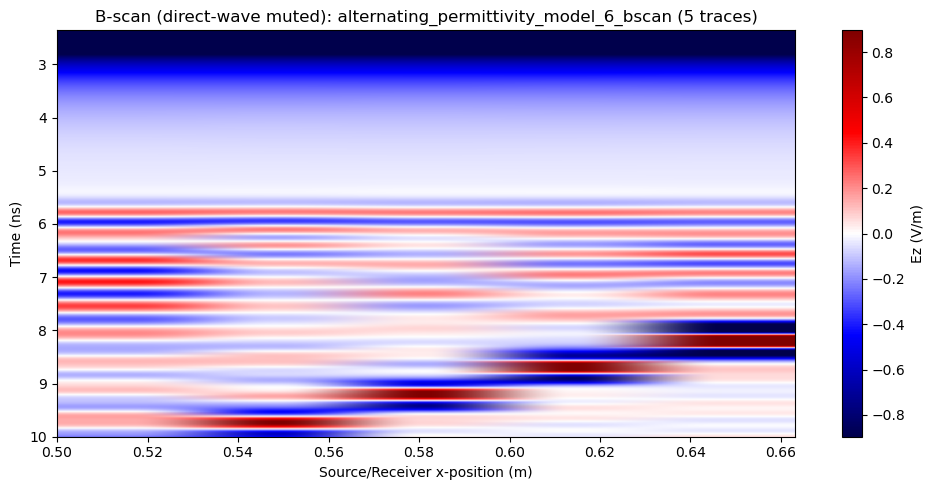

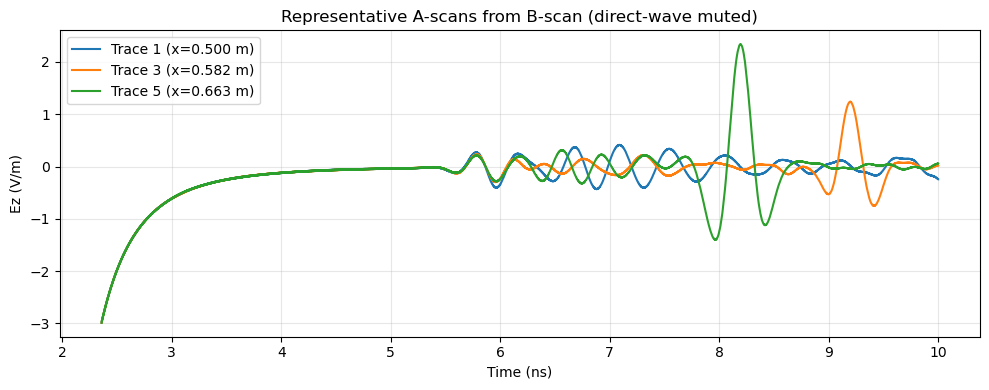

Loaded 5 traces from ..\True_and_Baseline_Models.
Sampling interval dt = 4.717e-13 s
Skipped first 5000 rows (2.359 ns start time).


In [10]:
# --- Plot B-scan results from multi-trace run ---
from pathlib import Path
import re

rxnumber = 1
rxcomponent = 'Ez'
base_name = 'alternating_permittivity_model_6_bscan'
model_dir = Path('..') / 'True_and_Baseline_Models'
in_file = model_dir / f'{base_name}.in'
skip_rows = 5000  # direct-wave mute: skip early-time samples

# Collect output files from gprMax -n run, e.g. ..._bscan1.out, ..._bscan2.out, ...
out_files = list(model_dir.glob(f'{base_name}[0-9]*.out'))

def _trace_index(path_obj):
    m = re.search(r'(\d+)$', path_obj.stem)
    return int(m.group(1)) if m else -1

out_files = sorted(out_files, key=_trace_index)

if not out_files:
    print('No per-trace B-scan output files found.')
    print(f'Expected files like: {base_name}1.out, {base_name}2.out, ...')
else:
    traces = []
    dt = None
    for f in out_files:
        data_i, dt_i = get_output_data(str(f), rxnumber, rxcomponent)
        traces.append(np.asarray(data_i).ravel())
        if dt is None:
            dt = dt_i

    # Ensure all traces use common time-sample count.
    nmin = min(len(t) for t in traces)
    traces = [t[:nmin] for t in traces]
    bscan = np.column_stack(traces)  # shape: [time, trace]

    # Parse source start x and src step from .in for physically meaningful x-axis.
    x0 = 0.0
    dx = 1.0
    if in_file.exists():
        txt = in_file.read_text()
        m_src = re.search(r'#hertzian_dipole:\s+z\s+([0-9eE+\-.]+)', txt)
        m_step = re.search(r'#src_steps:\s+([0-9eE+\-.]+)', txt)
        if m_src:
            x0 = float(m_src.group(1))
        if m_step:
            dx = float(m_step.group(1))

    ntr = bscan.shape[1]
    x = x0 + dx * np.arange(ntr)
    t_ns = np.arange(bscan.shape[0]) * dt * 1e9

    # Skip first rows dominated by direct wave.
    if skip_rows >= bscan.shape[0]:
        raise ValueError(f'skip_rows={skip_rows} is too large for trace length {bscan.shape[0]}.')
    bscan_gated = bscan[skip_rows:, :]
    t_ns_gated = t_ns[skip_rows:]

    plt.figure(figsize=(10, 5))
    vmax = np.max(np.abs(bscan_gated)) * 0.3
    plt.imshow(
        bscan_gated,
        aspect='auto',
        cmap='seismic',
        vmin=-vmax,
        vmax=vmax,
        extent=[x[0], x[-1], t_ns_gated[-1], t_ns_gated[0]]
    )
    plt.xlabel('Source/Receiver x-position (m)')
    plt.ylabel('Time (ns)')
    plt.title(f'B-scan (direct-wave muted): {base_name} ({ntr} traces)')
    cbar = plt.colorbar()
    cbar.set_label('Ez (V/m)')
    plt.tight_layout()
    plt.show()

    # Quick check: a few representative A-scans (also muted).
    sample_cols = sorted(set([0, ntr // 2, ntr - 1]))
    plt.figure(figsize=(10, 4))
    for c in sample_cols:
        plt.plot(t_ns_gated, bscan_gated[:, c], label=f'Trace {c+1} (x={x[c]:.3f} m)')
    plt.xlabel('Time (ns)')
    plt.ylabel('Ez (V/m)')
    plt.title('Representative A-scans from B-scan (direct-wave muted)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Loaded {ntr} traces from {model_dir}.')
    print(f'Sampling interval dt = {dt:.3e} s')
    print(f'Skipped first {skip_rows} rows ({t_ns[skip_rows]:.3f} ns start time).')

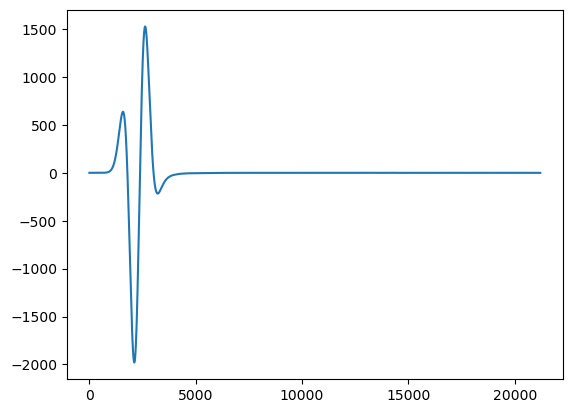

In [9]:
plt.plot(bscan[:, 0])